# Segmentación de vasos retinales — Grupo 3 (HRF)

**Curso:** Visión por Computador · **Dataset:** HRF · **Método:** determinístico (sin ML)
**Métricas objetivo:** Dice e IoU (Jaccard).

Este notebook orquesta el flujo de procesamiento definido en `src/` y lo evalúa sobre HRF:
cargar → explorar → preprocesar → segmentar → evaluar (Dice/IoU) → guardar en `predicted_masks/`.

In [4]:
import sys
!{sys.executable} -m pip install opencv-python scikit-image matplotlib pandas numpy

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import sys
from pathlib import Path

# Detecta la raíz del proyecto (la carpeta que contiene /src)
here = Path.cwd()
PROJECT_ROOT = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(PROJECT_ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src import config, dataset
from src import preprocessing as pp
from src import segmentation as seg
from src import metrics, pipeline

print("Proyecto :", PROJECT_ROOT)
print("Datos en :", config.DATA_DIR)
print("SCALE    :", config.SCALE)

Proyecto : C:\Users\infor\OneDrive\CARLOS PEREZ\MAESTRIA  UNI INTELIGENCIA ARTIFICIAL\III CICLO\CURSO Visión por Computador\04 Proyectos - Trabajos finales\TRABAJO PARCIAL
Datos en : C:\Users\infor\OneDrive\CARLOS PEREZ\MAESTRIA  UNI INTELIGENCIA ARTIFICIAL\III CICLO\CURSO Visión por Computador\04 Proyectos - Trabajos finales\TRABAJO PARCIAL\data\HRF
SCALE    : 0.5


## 1. Cargar el dataset

In [7]:
samples = dataset.list_samples()
print(f"{len(samples)} imágenes encontradas\n")
for s in samples[:6]:
    gt = s.gt_path.name if s.gt_path else "—"
    mk = s.mask_path.name if s.mask_path else "—"
    print(f"{s.name:<8} | img={s.image_path.name:<14} gt={gt:<12} mask={mk}")

45 imágenes encontradas

01_dr    | img=01_dr.JPG      gt=01_dr.tif    mask=01_dr_mask.tif
01_g     | img=01_g.jpg       gt=01_g.tif     mask=01_g_mask.tif
01_h     | img=01_h.jpg       gt=01_h.tif     mask=01_h_mask.tif
02_dr    | img=02_dr.JPG      gt=02_dr.tif    mask=02_dr_mask.tif
02_g     | img=02_g.jpg       gt=02_g.tif     mask=02_g_mask.tif
02_h     | img=02_h.jpg       gt=02_h.tif     mask=02_h_mask.tif


## 2. Explorar una imagen (RGB · canal verde · ground truth · FOV)

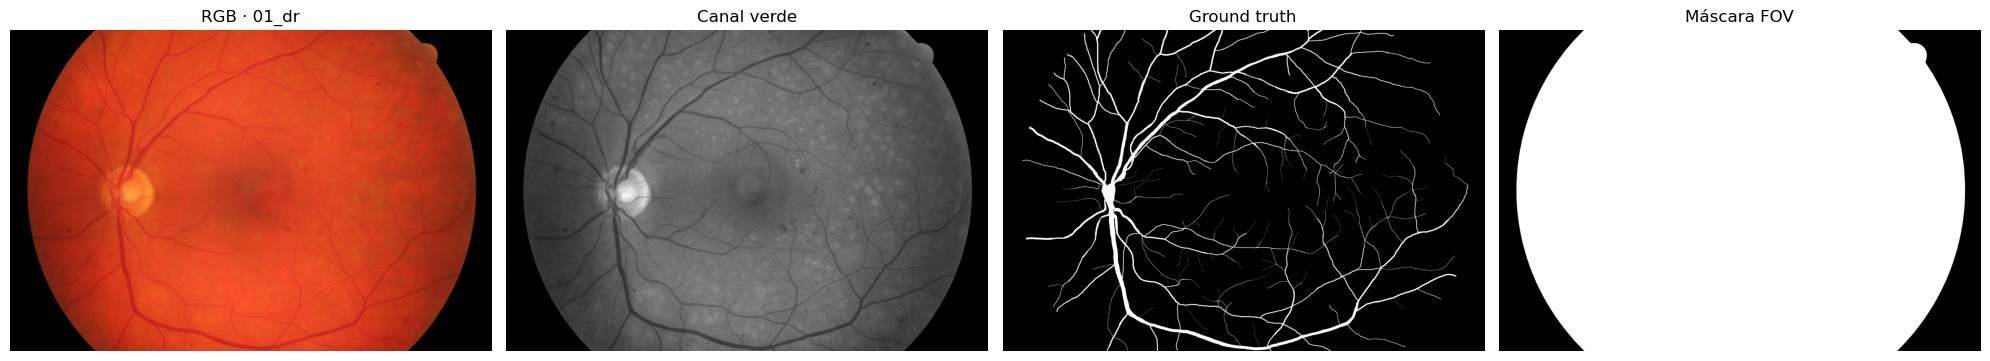

In [8]:
s = samples[0]
rgb   = dataset.read_rgb(s.image_path)
green = pp.green_channel(rgb)
gt    = dataset.read_binary(s.gt_path) if s.gt_path else None
fov   = dataset.read_binary(s.mask_path) if s.mask_path else None

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(rgb);                ax[0].set_title(f"RGB · {s.name}")
ax[1].imshow(green, cmap="gray"); ax[1].set_title("Canal verde")
if gt  is not None: ax[2].imshow(gt,  cmap="gray")
ax[2].set_title("Ground truth")
if fov is not None: ax[3].imshow(fov, cmap="gray")
ax[3].set_title("Máscara FOV")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 3. Preprocesamiento paso a paso

Trabajamos a `config.SCALE` para iterar rápido (HRF es 3504×2336).

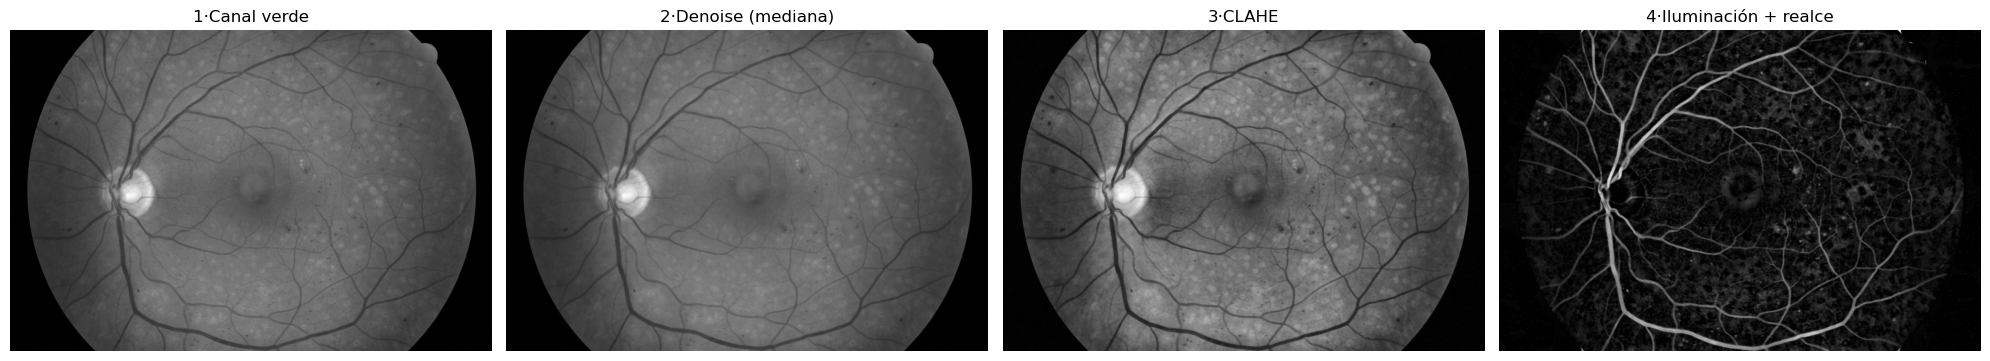

In [9]:
scale = config.SCALE
rgb_s = cv2.resize(rgb, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
fov_s = (cv2.resize(fov, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)
         if fov is not None else None)

g0 = pp.green_channel(rgb_s)
g1 = pp.denoise(g0, 5)
g2 = pp.clahe(g1, 2.0, 8)
g3 = pp.correct_illumination(g2, 55)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, im, t in zip(ax, [g0, g1, g2, g3],
                    ["1·Canal verde", "2·Denoise (mediana)", "3·CLAHE",
                     "4·Iluminación + realce"]):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Segmentar y comparar con el ground truth

{'dice': 0.2353, 'iou': 0.1333, 'sensitivity': 0.1423, 'specificity': 0.9957, 'accuracy': 0.9444}


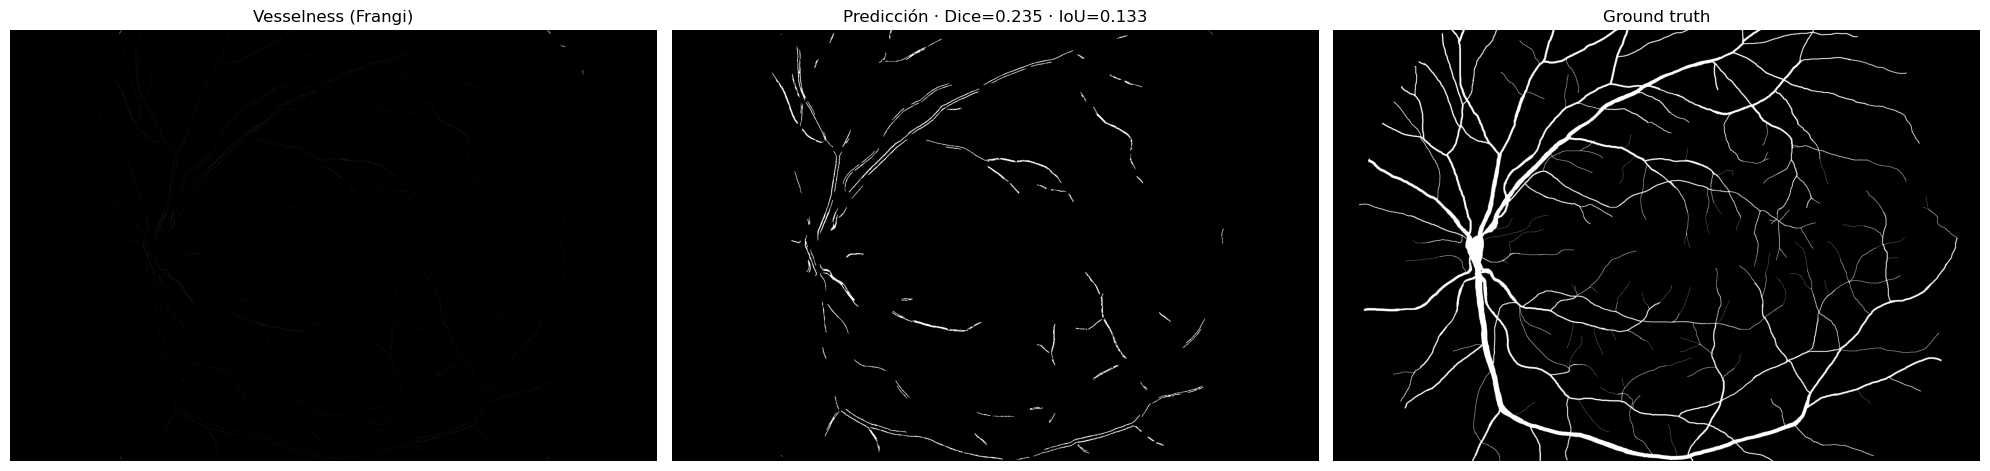

In [10]:
vness = seg.frangi_vesselness(g3, sigmas=config.DEFAULT_PARAMS["frangi_sigmas"])
pred  = seg.threshold_otsu(vness)
pred  = seg.clean(pred, fov_mask=fov_s, min_size=config.DEFAULT_PARAMS["min_size"])

title = "Predicción"
if gt is not None:
    pred_eval = cv2.resize(pred, (gt.shape[1], gt.shape[0]),
                           interpolation=cv2.INTER_NEAREST)
    m = metrics.all_metrics(pred_eval, gt, mask=fov)
    print({k: round(v, 4) for k, v in m.items()})
    title = f"Predicción · Dice={m['dice']:.3f} · IoU={m['iou']:.3f}"

fig, ax = plt.subplots(1, 3, figsize=(20, 7))
ax[0].imshow(vness, cmap="gray"); ax[0].set_title("Vesselness (Frangi)")
ax[1].imshow(pred,  cmap="gray"); ax[1].set_title(title)
if gt is not None: ax[2].imshow(gt, cmap="gray")
ax[2].set_title("Ground truth")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 5. Evaluar TODO el dataset (Dice/IoU) y guardar `predicted_masks/`

In [11]:
rows = pipeline.run(save=True, verbose=True)   # usa config.SCALE
df = pd.DataFrame(rows)

print("\n=== PROMEDIOS ===")
print(pd.Series(pipeline.summary(rows)).round(4))
df.head(10)

[ 1/45] 01_dr      Dice=0.6320  IoU=0.4619
[ 2/45] 01_g       Dice=0.6835  IoU=0.5192
[ 3/45] 01_h       Dice=0.6867  IoU=0.5229
[ 4/45] 02_dr      Dice=0.6394  IoU=0.4699
[ 5/45] 02_g       Dice=0.6887  IoU=0.5252
[ 6/45] 02_h       Dice=0.7423  IoU=0.5903
[ 7/45] 03_dr      Dice=0.3988  IoU=0.2490
[ 8/45] 03_g       Dice=0.6689  IoU=0.5026
[ 9/45] 03_h       Dice=0.6468  IoU=0.4780
[10/45] 04_dr      Dice=0.3930  IoU=0.2445
[11/45] 04_g       Dice=0.6901  IoU=0.5269
[12/45] 04_h       Dice=0.6865  IoU=0.5227
[13/45] 05_dr      Dice=0.6721  IoU=0.5061
[14/45] 05_g       Dice=0.6886  IoU=0.5251
[15/45] 05_h       Dice=0.7126  IoU=0.5536
[16/45] 06_dr      Dice=0.5585  IoU=0.3874
[17/45] 06_g       Dice=0.6879  IoU=0.5243
[18/45] 06_h       Dice=0.7433  IoU=0.5915
[19/45] 07_dr      Dice=0.6824  IoU=0.5179
[20/45] 07_g       Dice=0.6788  IoU=0.5138
[21/45] 07_h       Dice=0.7150  IoU=0.5564
[22/45] 08_dr      Dice=0.6198  IoU=0.4491
[23/45] 08_g       Dice=0.6547  IoU=0.4866
[24/45] 08_

,dice,iou,sensitivity,specificity,accuracy,name
0,0.631961,0.461946,0.764446,0.958080,0.946430,01_dr
1,0.683480,0.519157,0.685257,0.972495,0.949756,01_g
2,0.686717,0.522902,0.562432,0.989631,0.938106,01_h
3,0.639398,0.469937,0.717511,0.957038,0.938977,02_dr
4,0.688738,0.525248,0.693528,0.969033,0.944751,02_g
5,0.742347,0.590264,0.666378,0.982927,0.945917,02_h
6,0.398777,0.249046,0.781823,0.835323,0.831499,03_dr
7,0.668939,0.502560,0.638140,0.980206,0.956825,03_g
8,0.646832,0.478013,0.546331,0.979580,0.925416,03_h
9,0.392964,0.244527,0.764743,0.847658,0.842118,04_dr


## 6. Análisis por categoría (sano / retinopatía / glaucoma)

HRF: `_h` sano · `_dr` retinopatía diabética · `_g` glaucoma. Sirve para ver
dónde falla el flujo de procesamiento y justificarlo.

In [12]:
def categoria(name):
    if name.endswith("_h"):  return "sano"
    if name.endswith("_dr"): return "retinopatía"
    if name.endswith("_g"):  return "glaucoma"
    return "otro"

if not df.empty:
    df["categoria"] = df["name"].map(categoria)
    config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(config.RESULTS_DIR / "metricas_por_imagen.csv", index=False)
    print("Guardado: results/metricas_por_imagen.csv\n")
    print(df.groupby("categoria")[["dice", "iou"]].agg(["mean", "min", "max"]).round(4))

Guardado: results/metricas_por_imagen.csv

               dice                     iou                
               mean     min     max    mean     min     max
categoria                                                  
glaucoma     0.6723  0.5881  0.6960  0.5069  0.4165  0.5337
retinopatía  0.5995  0.3930  0.6824  0.4333  0.2445  0.5179
sano         0.7071  0.6468  0.7807  0.5482  0.4780  0.6403


## 7. Siguientes pasos (experimentos para subir el Dice)

- Poner `config.SCALE = 1.0` para el resultado final (mejor Dice, más lento).
- Probar `seg.threshold_adaptive(...)` en lugar de Otsu.
- Ajustar `DEFAULT_PARAMS`: `frangi_sigmas`, `clahe_clip`, `bg_kernel`, `min_size`.
- Las imágenes `_dr`/`_g` con lesiones (exudados/hemorragias) dan más falsos
  positivos → documenta cómo lo manejas. **Ese "por qué" es lo que más puntúa.**